In [40]:
# DSCI 552 — Homework 2
# ERIC OIWA - USC ID: 7863062627

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#a)
power_df = pd.read_excel("data/Folds5x2_pp.xlsx", sheet_name=0)
power_df.head()

print(power_df.shape)

(9568, 5)


In [8]:
#i there are 9568 rows and 5 columns in this set, the columns represent the different variables and the rows are a data point for each of them.
# as in the columns represent: T, AP, RH, V, and EP. and each row gives us the values of those 4 variables at the EP given on the fifth column

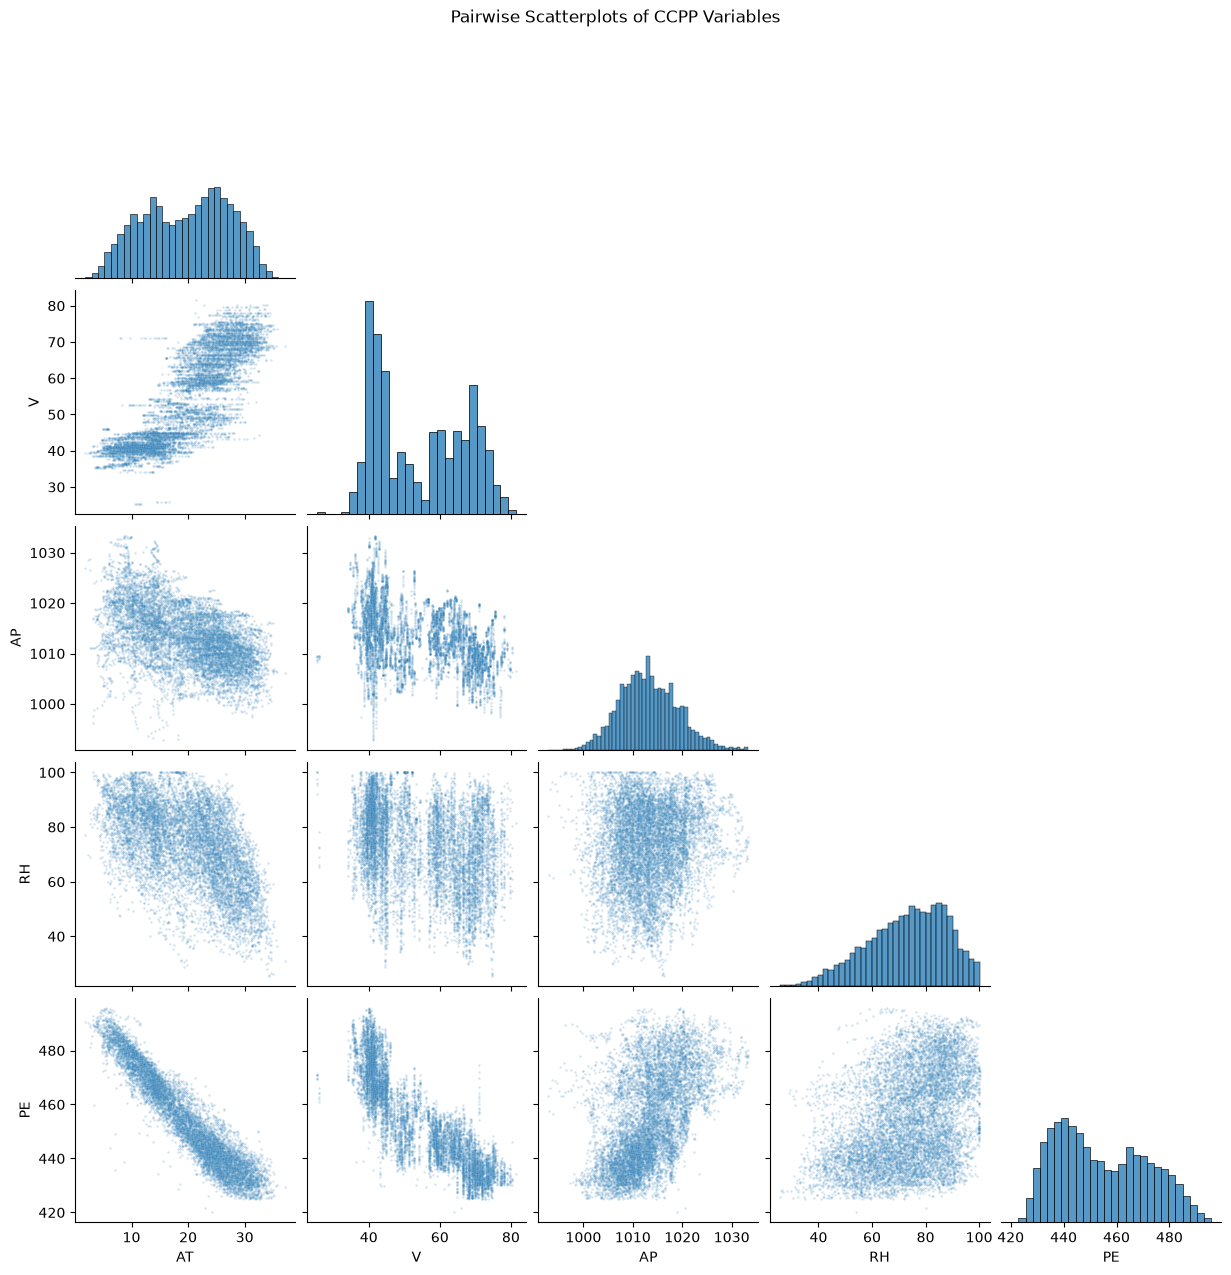

In [12]:

pair_grid = sns.pairplot(
    power_df,
    corner=True,
    height=2.5,
    plot_kws={"s": 3, "alpha": 0.2},
)
pair_grid.fig.suptitle("Pairwise Scatterplots of CCPP Variables", y=1.02)
plt.show()

In [13]:
#ii we can se a strong correlation between AT and PE, and V and PE, and V and AT. the others show weaker signs of a trend.
#as AT and V goes up we see that PE trends downwards and as V goes up so does AT, other trends are present but not was strong.


#iii
summary_stats = power_df.describe().T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats["IQR"] = summary_stats["75%"] - summary_stats["25%"]

summary_stats = summary_stats[["mean", "50%", "min", "max", "range", "25%", "75%", "IQR"]]
summary_stats = summary_stats.rename(columns={"50%": "median", "25%": "Q1", "75%": "Q3"})
summary_stats.round(2)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


In [15]:
#c)
simple_models = {}
simple_rows = []

for predictor in predictors:
    X = sm.add_constant(power_df[predictor])
    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model
    simple_rows.append({
        "predictor": predictor,
        "slope": model.params[predictor],
        "p_value": model.pvalues[predictor],
        "r_squared": model.rsquared,
    })

simple_results = pd.DataFrame(simple_rows).set_index("predictor")
simple_results

,slope,p_value,r_squared
predictor,,,
AT,-2.171320,0.0,0.898948
V,-1.168135,0.0,0.756518
AP,1.489872,0.0,0.268769
RH,0.455650,0.0,0.151939


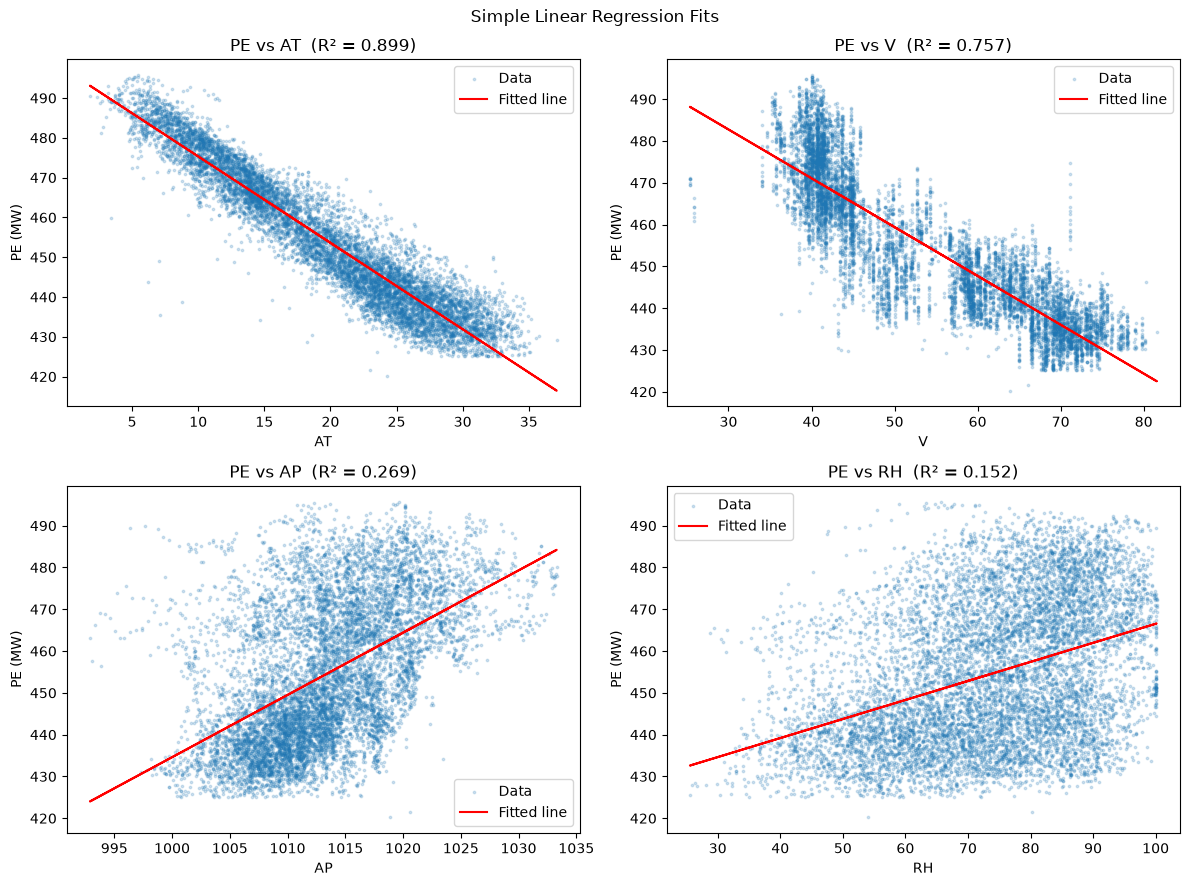

In [16]:
 #from what I see the slope is just a relationship of either negative or positive relationship at different rates, the p value is always zero because we have a huge sample
#and r squared is how tight it fits the model as a predictor, where R squared close to one show a strong correlation and low shows weak
#from table we see which values are strongly and correlated and which one was weak, the ones that are strongly correlated just happen to be the ones that are negative sloped compared to PE

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, predictor in zip(axes.flatten(), predictors):
    model = simple_models[predictor]
    ax.scatter(power_df[predictor], y, s=3, alpha=0.2, label="Data")
    ax.plot(power_df[predictor], model.fittedvalues, color="red", label="Fitted line")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE (MW)")
    ax.set_title(f"PE vs {predictor}  (R² = {model.rsquared:.3f})")
    ax.legend()

fig.suptitle("Simple Linear Regression Fits")
plt.tight_layout()
plt.show()


In [20]:
# as predicted from the table results we see that the columns that had the highest R squared fit the line better while the RH vs PE doesn't seem to have any correlation with the line
# I wouldn't remove any outliers as they don't seem to affect the line, and also due to the size of the sample, 10 or so outliers won't skew the regression fit heavily

#d)

X_all = sm.add_constant(power_df[predictors])
multiple_model = sm.OLS(y, X_all).fit()
print(multiple_model.summary())



                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:59:27   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

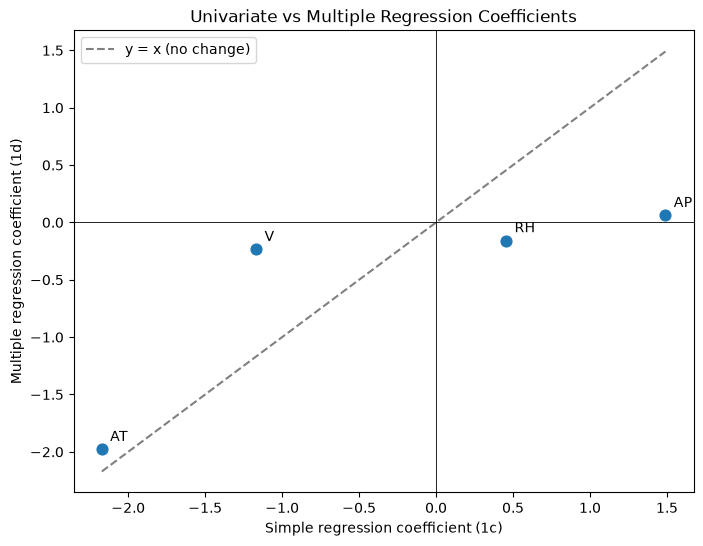

In [21]:
#now that they are all together we can note that we can reject the null hypothesis for all predictors looking at the P values
#also it's worth nothing that the slopes changed and the one that stand out is RH changing direction trend from positive to negative.
#it's worth noting that the R squared of all of them together is stronger than them individually even more so than the strongest one by itself.

#e
coef_comparison = pd.DataFrame({
    "simple": simple_results["slope"],
    "multiple": multiple_model.params[predictors],
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coef_comparison["simple"], coef_comparison["multiple"], s=60)

for predictor in predictors:
    ax.annotate(
        predictor,
        (coef_comparison.loc[predictor, "simple"], coef_comparison.loc[predictor, "multiple"]),
        textcoords="offset points",
        xytext=(6, 6),
    )

low = coef_comparison.min().min()
high = coef_comparison.max().max()
ax.plot([low, high], [low, high], linestyle="--", color="gray", label="y = x (no change)")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)

ax.set_xlabel("Simple regression coefficient (1c)")
ax.set_ylabel("Multiple regression coefficient (1d)")
ax.set_title("Univariate vs Multiple Regression Coefficients")
ax.legend()
plt.show()

In [26]:
#we can see that AP and V retain their main properties but go much closer to 0 in the multiple regression, 
#AT remains almost the same, being closer to the dash line, this shows it's not heavily correlated to the other variables and mostly acts on its own
#RH is the one that stands out changing signs, showing that its effect on the power consumption was mostly a result of something else affecting it originally


#f

In [25]:

poly_models = {}
poly_rows = []

for predictor in predictors:
    x = power_df[predictor]
    X_poly = pd.DataFrame({
        predictor: x,
        f"{predictor}^2": x ** 2,
        f"{predictor}^3": x ** 3,
    })
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly).fit()
    poly_models[predictor] = model
    poly_rows.append({
        "predictor": predictor,
        "p_linear": model.pvalues[predictor],
        "p_squared": model.pvalues[f"{predictor}^2"],
        "p_cubed": model.pvalues[f"{predictor}^3"],
        "r_squared_cubic": model.rsquared,
        "r_squared_linear": simple_models[predictor].rsquared,
    })

poly_results = pd.DataFrame(poly_rows).set_index("predictor")
poly_results

,p_linear,p_squared,p_cubed,r_squared_cubic,r_squared_linear
predictor,,,,,
AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883,0.898948
V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022,0.756518
AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863,0.268769
RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743,0.151939


In [28]:
#yes there is evidence of nonlinearity for all predictors, the only one that seems less significant is V
#however the gain on R squared is very small for AP and RH while AT and V seem to change more from R linear to R cubic



#g
interaction_model = smf.ols("PE ~ (AT + V + AP + RH) ** 2", data=power_df).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:11:44   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [29]:
#the ones that are signficant are ATxAP at P>t at 0.452
# and less so we have VxRH and APxRH, respectively at 0.086 and 0.034
#all the other associations are negligible


In [31]:
#h 
train_df, test_df = train_test_split(power_df, test_size=0.3, random_state=67) #random sample size of 70 percent and 30 percent for test

linear_model = smf.ols("PE ~ AT + V + AP + RH", data=train_df).fit() 

linear_train_mse = mean_squared_error(train_df["PE"], linear_model.predict(train_df))
linear_test_mse = mean_squared_error(test_df["PE"], linear_model.predict(test_df))

print(f"Linear model  - train MSE: {linear_train_mse:.3f}, test MSE: {linear_test_mse:.3f}")


Linear model  - train MSE: 21.571, test MSE: 18.916


In [32]:
# using all predictors 
full_formula = "PE ~ (AT + V + AP + RH) ** 2 + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
full_model = smf.ols(full_formula, data=train_df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     6857.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:50:55   Log-Likelihood:                -19352.
No. Observations:                6697   AIC:                         3.873e+04
Df Residuals:                    6682   BIC:                         3.884e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7302.0553   1485.333     -4.916      0.0

In [33]:
step1_formula = (
    "PE ~ AT + V + AP + RH"
    " + AT:V + AT:AP + AT:RH + V:AP + AP:RH"
    " + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
)
step1_model = smf.ols(step1_formula, data=train_df).fit()
print(step1_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     7386.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:38:27   Log-Likelihood:                -19352.
No. Observations:                6697   AIC:                         3.873e+04
Df Residuals:                    6683   BIC:                         3.883e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7260.9457   1483.051     -4.896      0.0

In [34]:
step2_formula = (
    "PE ~ AT + V + AP + RH"
    " + AT:V + AT:RH + V:AP + AP:RH"
    " + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
)
step2_model = smf.ols(step2_formula, data=train_df).fit()
print(step2_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     8002.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:39:57   Log-Likelihood:                -19352.
No. Observations:                6697   AIC:                         3.873e+04
Df Residuals:                    6684   BIC:                         3.882e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7791.1635   1293.753     -6.022      0.0

In [35]:
step3_formula = (
    "PE ~ AT + V + AP + RH"
    " + AT:V + AT:RH + V:AP + AP:RH"
    " + I(AT ** 2) + I(AP ** 2) + I(RH ** 2)"
)
step3_model = smf.ols(step3_formula, data=train_df).fit()
print(step3_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     8727.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:40:33   Log-Likelihood:                -19353.
No. Observations:                6697   AIC:                         3.873e+04
Df Residuals:                    6685   BIC:                         3.881e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7913.5286   1291.101     -6.129      0.0

In [36]:
final_train_mse = mean_squared_error(train_df["PE"], step3_model.predict(train_df))
final_test_mse = mean_squared_error(test_df["PE"], step3_model.predict(test_df))

print(f"Linear model  - train MSE: {linear_train_mse:.3f}, test MSE: {linear_test_mse:.3f}")
print(f"Pruned model  - train MSE: {final_train_mse:.3f}, test MSE: {final_test_mse:.3f}")

Linear model  - train MSE: 21.571, test MSE: 18.916
Pruned model  - train MSE: 18.949, test MSE: 16.203


In [37]:
#after checking the linear model MSE and looking at the P values on the data, the ones that had high P values were removed
#then running the same test checking for MSE on the train and test data, we see that the MSE has reduced, and its train and test MSE are fairly close to each other



In [41]:
#i KNN Regression
X_train = train_df[predictors]
X_test = test_df[predictors]
y_train = train_df["PE"]
y_test = test_df["PE"]

k_values = list(range(1, 101))
raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    raw_train_mse.append(mean_squared_error(y_train, knn.predict(X_train)))
    raw_test_mse.append(mean_squared_error(y_test, knn.predict(X_test)))

best_raw_index = raw_test_mse.index(min(raw_test_mse))
print(f"Raw features - best k: {k_values[best_raw_index]}, test MSE: {raw_test_mse[best_raw_index]:.3f}")

Raw features - best k: 6, test MSE: 14.504


In [42]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_train_mse = []
scaled_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scaled_train_mse.append(mean_squared_error(y_train, knn.predict(X_train_scaled)))
    scaled_test_mse.append(mean_squared_error(y_test, knn.predict(X_test_scaled)))

best_scaled_index = scaled_test_mse.index(min(scaled_test_mse))
print(f"Normalized features - best k: {k_values[best_scaled_index]}, test MSE: {scaled_test_mse[best_scaled_index]:.3f}")

Normalized features - best k: 9, test MSE: 13.160


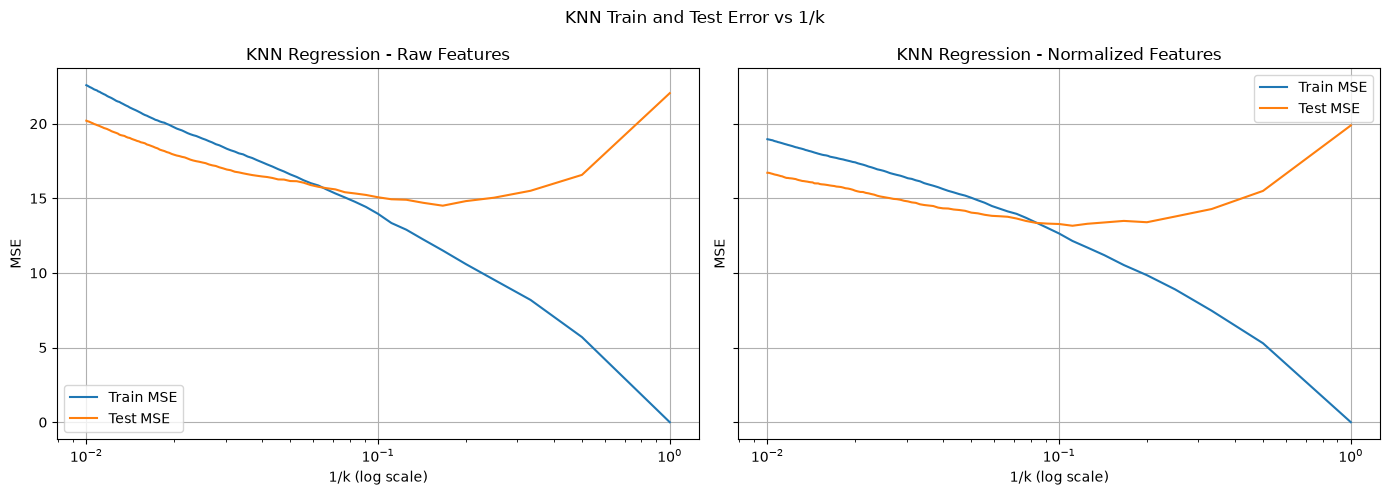

In [43]:
inverse_k = [1 / k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(inverse_k, raw_train_mse, label="Train MSE")
axes[0].plot(inverse_k, raw_test_mse, label="Test MSE")
axes[0].set_title("KNN Regression - Raw Features")

axes[1].plot(inverse_k, scaled_train_mse, label="Train MSE")
axes[1].plot(inverse_k, scaled_test_mse, label="Test MSE")
axes[1].set_title("KNN Regression - Normalized Features")

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("1/k (log scale)")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(True)

fig.suptitle("KNN Train and Test Error vs 1/k")
plt.tight_layout()
plt.show()

In [45]:

#j compare the results



model_comparison = pd.DataFrame({
    "model": [
        "Linear (4 predictors)",
        "Pruned interaction/quadratic",
        f"KNN raw (k={k_values[best_raw_index]})",
        f"KNN normalized (k={k_values[best_scaled_index]})",
    ],
    "train_mse": [
        linear_train_mse,
        final_train_mse,
        raw_train_mse[best_raw_index],
        scaled_train_mse[best_scaled_index],
    ],
    "test_mse": [
        linear_test_mse,
        final_test_mse,
        raw_test_mse[best_raw_index],
        scaled_test_mse[best_scaled_index],
    ],
}).set_index("model")

model_comparison.round(3)

,train_mse,test_mse
model,,
Linear (4 predictors),21.571,18.916
Pruned interaction/quadratic,18.949,16.203
KNN raw (k=6),11.502,14.504
KNN normalized (k=9),12.142,13.160


In [46]:
#the most accurate results is the KNN normalized by  decent amount compared to the linear both methods, however the raw to KNN yieleded fairly similar results
#The model with the least overfitting is the KNN normalized, with a diference of 1 on the MSE for train and test, all other methods seems to be around a value of 2 to 3 in difference
#The KNN method is more overall and allows us to predict the Power in general but doesn't gives us how each factor affects the output
#normalization barely changed the results.

In [47]:
#ISLR 2.4.1

#For each of parts (a) through (d), indicate whether we would generally
#expect the performance of a flexible statistical learning method to be
#better or worse than an inflexible method. Justify your answer.

#a) The sample size n is extremely large, and the number of predictors p is small

# for a large sample size and few predictors noise and outliers should get "drowned" in the large amount of data and therefore we can be flexible as the sheer amount of data should average out to a desired trend

#b) The number of predictors p is extremely large, and the number of observations n is small.

#for b we want to be unflexible as a small sample will highlight outliers and noise more and having many predictors will make the learning method try to interpret every single detail if left flexible

#c)  The relationship between the predictors and response is highly non-linear

#for c, having a nonlinear relationship requires more flexibility, because it requires the trend to be able to adapt to those non linear relationships, if unflexible the data will ignore some trends

#d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely high.

#for d, we want to be unflexible, because a lot of the data will be away from a trend, if flexible the trend will be overfitted and will not identify anything that is useful



In [48]:
#ISLR 2.4.7
#a) using d = sqrt(X1^2+X2^2+X3^2) we get the following results
# 1  3  red
# 2  2  red
# 3  3.16 red
#4   2.24 green
#5   1.41 green
#6   1.73 red

#b) for K=1 my prediction is green, the neared result is 1.41 and it's green

#c) for K=3 my prediciton is red, the closes numbers are 5,6, and 2 and 2 of them are red while only one is green

#d) since it's non linear we would want K to be small to give us more flexibility to interpret, if K is large it will miss the trend and identify most things as red, making it bias.


In [1]:
#note: used AI to search and learn how to use most of the tools, the few that I didn't use were because I used it in and learned in HW 1